# SVM — Linear and RBF Kernel Comparison

Two SVM variants are evaluated:

**LinearSVC (full training data)**  
Trains in ~1 second on 291K samples. Linear decision boundaries. Uses `class_weight='balanced'` and is calibrated with Platt scaling for probability output. Good baseline for whether a linear SVM can find the Fatality cluster.

**RBF SVC (stratified subsample)**  
RBF kernel is O(n²) — infeasible on 291K samples (~23 hours). Instead we subsample: keep **all 801 Fatality** training samples and draw 4,000 each from No Injury and Injury. Evaluated on the **full** 85,534-row test set. The RBF kernel can find tight nonlinear clusters that tree ensembles miss.

**Key requirement:** SVM is distance-based, so all features must be standardized with `StandardScaler` before fitting.

---
## 1. Load libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score, roc_auc_score
)

plt.style.use('seaborn-v0_8')
RANDOM_STATE = 42
CLASS_NAMES  = ['No Injury', 'Injury', 'Fatality']
print('Libraries loaded.')

Libraries loaded.


---
## 2. Load data

In [2]:
df = pd.read_csv('../../data/processed/cleaned_collisions.csv', low_memory=False)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
for cls, name in enumerate(CLASS_NAMES):
    n = (df['severity'] == cls).sum()
    print(f'  {name:12s}: {n:>7,}  ({n/len(df)*100:.2f}%)')

Shape: 394,751 rows x 29 columns
  No Injury   : 230,535  (58.40%)
  Injury      : 163,164  (41.33%)
  Fatality    :   1,052  (0.27%)


---
## 3. Feature engineering

Identical to all previous notebooks — same feature set for fair comparison.

In [3]:
df = df.copy()

def month_to_season(m):
    if m in [12, 1, 2]: return 'winter'
    if m in [3, 4, 5]:  return 'spring'
    if m in [6, 7, 8]:  return 'summer'
    return 'fall'

def hour_to_period(h):
    if h < 5:  return 'late_night'
    if h < 10: return 'morning'
    if h < 15: return 'midday'
    if h < 19: return 'evening'
    return 'night'

df['season']      = df['month'].apply(month_to_season)
df['time_of_day'] = df['hour'].apply(hour_to_period)

vt = ['vehicle_type_1', 'vehicle_type_2']
df['bike_involved']       = df[vt].isin(['BIKE','E-BIKE','E-SCOOTER']).any(axis=1).astype(int)
df['motorcycle_involved'] = df[vt].isin(['MOTORCYCLE','MOPED']).any(axis=1).astype(int)
df['unknown_factor']      = df[['factor_vehicle_1','factor_vehicle_2']].isin(['UNSPECIFIED','UNKNOWN']).any(axis=1).astype(int)

TRUCK_LABELS = ['TRUCK','BOX TRUCK','TRACTOR TRUCK DIESEL','TRACTOR TRUCK GASOLINE',
                'FLAT BED','GARBAGE OR REFUSE','DUMP','TANKER','CONCRETE MIXER']
df['truck_involved'] = df[vt].isin(TRUCK_LABELS).any(axis=1).astype(int)
df['num_vehicles']   = df['vehicle_type_1'].notna().astype(int) + df['vehicle_type_2'].notna().astype(int)

dark = ((df['hour'] >= 20) | (df['hour'] <= 5)).astype(int)
df['bike_dark'] = df['bike_involved'] * dark
df['moto_rush'] = df['motorcycle_involved'] * df['is_rush_hour']

df['lat_bin']   = pd.qcut(df['latitude'],  q=5, labels=['lat0','lat1','lat2','lat3','lat4'], duplicates='drop')
df['lon_bin']   = pd.qcut(df['longitude'], q=5, labels=['lon0','lon1','lon2','lon3','lon4'], duplicates='drop')
df['grid_cell'] = df['lat_bin'].astype(str) + '_' + df['lon_bin'].astype(str)

print('Feature engineering done.')

Feature engineering done.


---
## 4. Define features, split, preprocess

`StandardScaler` is applied after the train/test split — scaler is fit on training data only to avoid leaking test distribution statistics.

In [4]:
DROP_COLS = [
    'severity','num_injured','num_killed',
    'number_of_pedestrians_injured','number_of_pedestrians_killed',
    'number_of_cyclist_injured','number_of_cyclist_killed',
    'number_of_motorist_injured','number_of_motorist_killed',
    'collision_id','crash_date','crash_time',
    'on_street_name','cross_street_name','location',
    'zip_code','year','latitude','longitude','lat_bin','lon_bin',
]
feature_cols = [c for c in df.columns if c not in DROP_COLS]
X = df[feature_cols].copy()
y = df['severity'].copy()

train_mask = df['year'].isin([2022, 2023, 2024])
test_mask  = df['year'] == 2025
X_train_raw, y_train = X[train_mask].copy(), y[train_mask].copy()
X_test_raw,  y_test  = X[test_mask].copy(),  y[test_mask].copy()

# --- categorical encoding ---
def cap_top_n(series, n=12):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), 'OTHER')

X_train_enc = X_train_raw.copy()
X_test_enc  = X_test_raw.copy()
for col in ['vehicle_type_1','vehicle_type_2','factor_vehicle_1','factor_vehicle_2']:
    if col in X_train_enc.columns:
        X_train_enc[col] = cap_top_n(X_train_enc[col])
        X_test_enc[col]  = X_test_enc[col].where(X_test_enc[col].isin(X_train_enc[col].unique()), 'OTHER')

CAT_COLS = ['borough','day_of_week','season','time_of_day','grid_cell',
            'vehicle_type_1','vehicle_type_2','factor_vehicle_1','factor_vehicle_2']
CAT_COLS = [c for c in CAT_COLS if c in X_train_enc.columns]
X_train_enc = pd.get_dummies(X_train_enc, columns=CAT_COLS, drop_first=True)
X_test_enc  = pd.get_dummies(X_test_enc,  columns=CAT_COLS, drop_first=True)
X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
for df_ in [X_train_enc, X_test_enc]:
    for col in df_.select_dtypes(include='category').columns:
        df_[col] = df_[col].astype(float)
X_train_enc = X_train_enc.fillna(0).astype(float)
X_test_enc  = X_test_enc.fillna(0).astype(float)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# --- StandardScaler (fit on train only) ---
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_enc)
X_test  = scaler.transform(X_test_enc)

print(f'X_train: {X_train.shape}   X_test: {X_test.shape}')
print(f'Train Fatality count: {(y_train==2).sum():,}')
print(f'Test  Fatality count: {(y_test==2).sum():,}')

X_train: (291808, 101)   X_test: (85534, 101)
Train Fatality count: 801
Test  Fatality count: 214


---
## 5. LinearSVC — full training data

LinearSVC uses a one-vs-rest strategy internally.  
We wrap it with `CalibratedClassifierCV` (Platt scaling, cv=3) to get proper probability estimates for threshold tuning.

In [5]:
base_lsvc = LinearSVC(
    C=0.1,
    class_weight='balanced',
    max_iter=2000,
    random_state=RANDOM_STATE
)
lsvc = CalibratedClassifierCV(base_lsvc, cv=3)
lsvc.fit(X_train, y_train)

y_pred_lsvc   = lsvc.predict(X_test)
y_proba_lsvc  = lsvc.predict_proba(X_test)

print('=== LinearSVC (default threshold) ===')
print(classification_report(y_test, y_pred_lsvc, target_names=CLASS_NAMES))
print(f"Macro F1:        {f1_score(y_test, y_pred_lsvc, average='macro'):.4f}")
print(f"Fatality recall: {recall_score(y_test, y_pred_lsvc, labels=[2], average='macro', zero_division=0):.4f}")
print(f"Injury recall:   {recall_score(y_test, y_pred_lsvc, labels=[1], average='macro', zero_division=0):.4f}")

=== LinearSVC (default threshold) ===
              precision    recall  f1-score   support

   No Injury       0.67      0.88      0.76     48121
      Injury       0.74      0.45      0.56     37199
    Fatality       0.00      0.00      0.00       214

    accuracy                           0.69     85534
   macro avg       0.47      0.44      0.44     85534
weighted avg       0.70      0.69      0.67     85534

Macro F1:        0.4394
Fatality recall: 0.0000
Injury recall:   0.4481


### 5a. Threshold tuning — LinearSVC

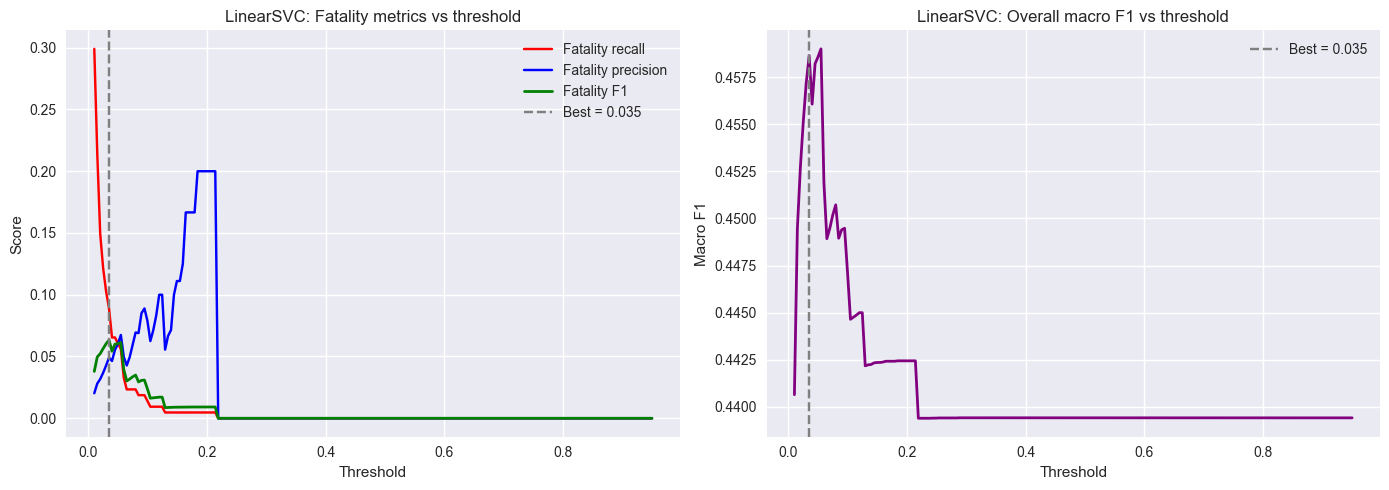

Best threshold: 0.0349
  Fatality recall:    0.0888
  Fatality precision: 0.0491
  Fatality F1:        0.0632
  Overall macro F1:   0.4586


In [6]:
def sweep_threshold(fat_proba, y_pred_default, y_test, label='Model'):
    thresholds = np.linspace(0.01, 0.95, 190)
    fat_rec, fat_prec, fat_f1, macro_f1 = [], [], [], []
    for t in thresholds:
        y_t = np.where(fat_proba >= t, 2, y_pred_default)
        fat_rec.append(recall_score(y_test, y_t, labels=[2], average='macro', zero_division=0))
        fat_prec.append(precision_score(y_test, y_t, labels=[2], average='macro', zero_division=0))
        fat_f1.append(f1_score(y_test, y_t, labels=[2], average='macro', zero_division=0))
        macro_f1.append(f1_score(y_test, y_t, average='macro', zero_division=0))
    fat_rec, fat_prec = np.array(fat_rec), np.array(fat_prec)
    fat_f1, macro_f1  = np.array(fat_f1),  np.array(macro_f1)
    best_idx   = np.argmax(fat_f1)
    best_t     = thresholds[best_idx]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    ax.plot(thresholds, fat_rec,  label='Fatality recall',    color='red')
    ax.plot(thresholds, fat_prec, label='Fatality precision', color='blue')
    ax.plot(thresholds, fat_f1,   label='Fatality F1',        color='green', linewidth=2)
    ax.axvline(best_t, linestyle='--', color='gray', label=f'Best = {best_t:.3f}')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.set_title(f'{label}: Fatality metrics vs threshold'); ax.legend(); ax.grid(True)

    ax = axes[1]
    ax.plot(thresholds, macro_f1, color='purple', linewidth=2)
    ax.axvline(best_t, linestyle='--', color='gray', label=f'Best = {best_t:.3f}')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Macro F1')
    ax.set_title(f'{label}: Overall macro F1 vs threshold'); ax.legend(); ax.grid(True)
    plt.tight_layout(); plt.show()

    print(f'Best threshold: {best_t:.4f}')
    print(f'  Fatality recall:    {fat_rec[best_idx]:.4f}')
    print(f'  Fatality precision: {fat_prec[best_idx]:.4f}')
    print(f'  Fatality F1:        {fat_f1[best_idx]:.4f}')
    print(f'  Overall macro F1:   {macro_f1[best_idx]:.4f}')
    return best_t, thresholds, fat_rec, fat_prec, fat_f1, macro_f1

best_t_lsvc, *lsvc_curves = sweep_threshold(
    y_proba_lsvc[:, 2], y_pred_lsvc, y_test, label='LinearSVC'
)

In [7]:
y_pred_lsvc_tuned = np.where(y_proba_lsvc[:, 2] >= best_t_lsvc, 2, y_pred_lsvc)

print(f'=== LinearSVC (tuned threshold = {best_t_lsvc:.4f}) ===')
print(classification_report(y_test, y_pred_lsvc_tuned, target_names=CLASS_NAMES))
print(f"Macro F1:        {f1_score(y_test, y_pred_lsvc_tuned, average='macro'):.4f}")
print(f"Fatality recall: {recall_score(y_test, y_pred_lsvc_tuned, labels=[2], average='macro', zero_division=0):.4f}")
print(f"Injury recall:   {recall_score(y_test, y_pred_lsvc_tuned, labels=[1], average='macro', zero_division=0):.4f}")

=== LinearSVC (tuned threshold = 0.0349) ===
              precision    recall  f1-score   support

   No Injury       0.67      0.88      0.76     48121
      Injury       0.74      0.44      0.55     37199
    Fatality       0.05      0.09      0.06       214

    accuracy                           0.69     85534
   macro avg       0.49      0.47      0.46     85534
weighted avg       0.70      0.69      0.67     85534

Macro F1:        0.4586
Fatality recall: 0.0888
Injury recall:   0.4410


---
## 6. RBF SVC — stratified subsample

RBF SVM is O(n²) in training. On 291K samples that would take ~23 hours.  
Strategy: keep **all 801 Fatality** training samples, draw 4,000 each from No Injury and Injury.  
Total subsample: 8,801. Evaluated on the full 85,534-row test set.

`class_weight='balanced'` still applies within the subsample, giving Fatality an additional ~3.7× weight.

In [8]:
SUBSAMPLE_PER_CLASS = 4000
rng = np.random.default_rng(RANDOM_STATE)

idx_fat = np.where(y_train == 2)[0]                                   # all 801
idx_ni  = rng.choice(np.where(y_train == 0)[0], SUBSAMPLE_PER_CLASS, replace=False)
idx_inj = rng.choice(np.where(y_train == 1)[0], SUBSAMPLE_PER_CLASS, replace=False)
sub_idx = np.concatenate([idx_fat, idx_ni, idx_inj])

X_sub = X_train[sub_idx]
y_sub = y_train.iloc[sub_idx].reset_index(drop=True)

print(f'Subsample size: {len(X_sub):,}')
for cls, name in enumerate(CLASS_NAMES):
    n = (y_sub == cls).sum()
    print(f'  {name}: {n:,} ({n/len(y_sub)*100:.1f}%)')

rbf = SVC(
    C=10,
    kernel='rbf',
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)
rbf.fit(X_sub, y_sub)

print(f'\nSupport vectors per class:')
for cls, name in enumerate(CLASS_NAMES):
    print(f'  {name}: {rbf.n_support_[cls]:,}')

Subsample size: 8,801
  No Injury: 4,000 (45.4%)
  Injury: 4,000 (45.4%)
  Fatality: 801 (9.1%)



Support vectors per class:
  No Injury: 3,174
  Injury: 3,470
  Fatality: 761


In [9]:
y_pred_rbf  = rbf.predict(X_test)
y_proba_rbf = rbf.predict_proba(X_test)

print('=== RBF SVC (default threshold, trained on subsample) ===')
print(classification_report(y_test, y_pred_rbf, target_names=CLASS_NAMES))
print(f"Macro F1:        {f1_score(y_test, y_pred_rbf, average='macro'):.4f}")
print(f"Fatality recall: {recall_score(y_test, y_pred_rbf, labels=[2], average='macro', zero_division=0):.4f}")
print(f"Injury recall:   {recall_score(y_test, y_pred_rbf, labels=[1], average='macro', zero_division=0):.4f}")
print(f"ROC-AUC (Fatality vs rest): {roc_auc_score((y_test==2).astype(int), y_proba_rbf[:,2]):.4f}")

=== RBF SVC (default threshold, trained on subsample) ===
              precision    recall  f1-score   support

   No Injury       0.70      0.66      0.68     48121
      Injury       0.60      0.56      0.58     37199
    Fatality       0.01      0.34      0.03       214

    accuracy                           0.62     85534
   macro avg       0.44      0.52      0.43     85534
weighted avg       0.66      0.62      0.64     85534

Macro F1:        0.4301
Fatality recall: 0.3411
Injury recall:   0.5632
ROC-AUC (Fatality vs rest): 0.7752


### 6a. Threshold tuning — RBF SVC

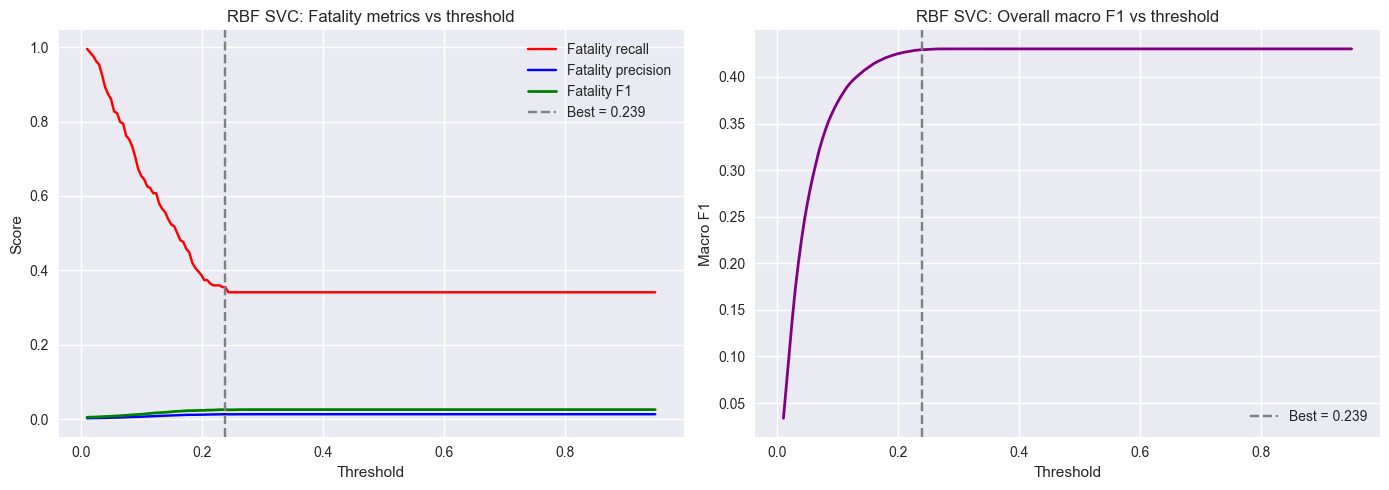

Best threshold: 0.2388
  Fatality recall:    0.3551
  Fatality precision: 0.0135
  Fatality F1:        0.0260
  Overall macro F1:   0.4293


In [10]:
best_t_rbf, *rbf_curves = sweep_threshold(
    y_proba_rbf[:, 2], y_pred_rbf, y_test, label='RBF SVC'
)

In [11]:
y_pred_rbf_tuned = np.where(y_proba_rbf[:, 2] >= best_t_rbf, 2, y_pred_rbf)

print(f'=== RBF SVC (tuned threshold = {best_t_rbf:.4f}) ===')
print(classification_report(y_test, y_pred_rbf_tuned, target_names=CLASS_NAMES))
print(f"Macro F1:        {f1_score(y_test, y_pred_rbf_tuned, average='macro'):.4f}")
print(f"Fatality recall: {recall_score(y_test, y_pred_rbf_tuned, labels=[2], average='macro', zero_division=0):.4f}")
print(f"Injury recall:   {recall_score(y_test, y_pred_rbf_tuned, labels=[1], average='macro', zero_division=0):.4f}")

=== RBF SVC (tuned threshold = 0.2388) ===
              precision    recall  f1-score   support

   No Injury       0.70      0.66      0.68     48121
      Injury       0.60      0.56      0.58     37199
    Fatality       0.01      0.36      0.03       214

    accuracy                           0.62     85534
   macro avg       0.44      0.53      0.43     85534
weighted avg       0.66      0.62      0.64     85534

Macro F1:        0.4293
Fatality recall: 0.3551
Injury recall:   0.5601


---
## 7. Side-by-side confusion matrices

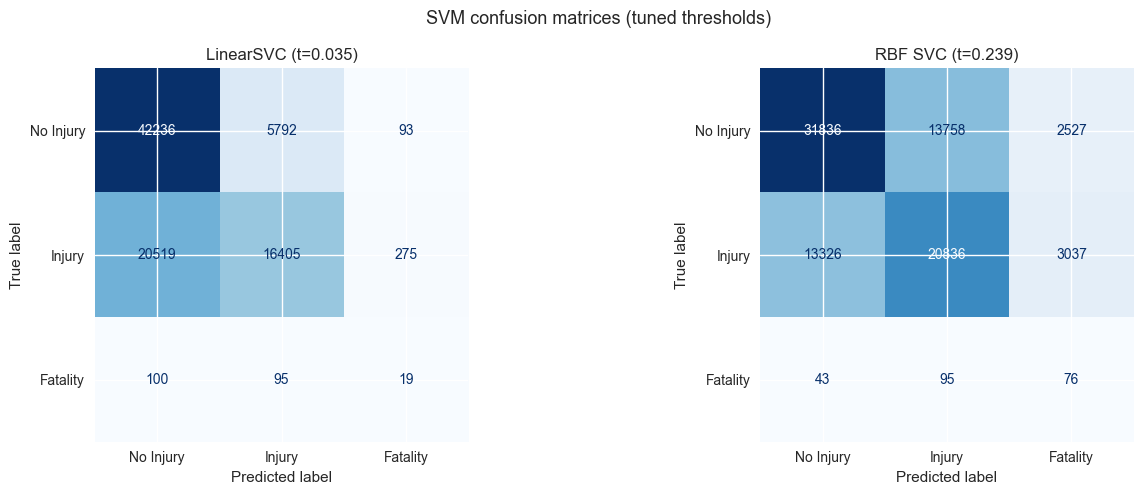

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(
    axes,
    [y_pred_lsvc_tuned, y_pred_rbf_tuned],
    [f'LinearSVC (t={best_t_lsvc:.3f})', f'RBF SVC (t={best_t_rbf:.3f})']
):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred), display_labels=CLASS_NAMES
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
plt.suptitle('SVM confusion matrices (tuned thresholds)', fontsize=13)
plt.tight_layout(); plt.show()

---
## 8. Full model comparison

In [13]:
summary = pd.DataFrame([
    {'Model': 'Logistic Regression (baseline)',      'Macro F1': 0.430, 'Fatality Recall': 0.000, 'Injury Recall': 0.430},
    {'Model': 'Random Forest v1',                    'Macro F1': 0.430, 'Fatality Recall': 0.000, 'Injury Recall': 0.430},
    {'Model': 'RF cleaner model',                    'Macro F1': 0.471, 'Fatality Recall': 0.196, 'Injury Recall': 0.560},
    {'Model': 'RF + SMOTE',                          'Macro F1': 0.497, 'Fatality Recall': 0.112, 'Injury Recall': 0.567},
    {'Model': 'XGBoost multi-class (tuned)',          'Macro F1': 0.434, 'Fatality Recall': 0.603, 'Injury Recall': 0.479},
    {'Model': 'Two-Stage XGBoost (best F1)',          'Macro F1': 0.480, 'Fatality Recall': 0.201, 'Injury Recall': 0.591},
    {
        'Model': f'LinearSVC (tuned t={best_t_lsvc:.3f})',
        'Macro F1':        round(f1_score(y_test, y_pred_lsvc_tuned, average='macro'), 3),
        'Fatality Recall': round(recall_score(y_test, y_pred_lsvc_tuned, labels=[2], average='macro', zero_division=0), 3),
        'Injury Recall':   round(recall_score(y_test, y_pred_lsvc_tuned, labels=[1], average='macro', zero_division=0), 3),
    },
    {
        'Model': f'RBF SVC (tuned t={best_t_rbf:.3f})',
        'Macro F1':        round(f1_score(y_test, y_pred_rbf_tuned, average='macro'), 3),
        'Fatality Recall': round(recall_score(y_test, y_pred_rbf_tuned, labels=[2], average='macro', zero_division=0), 3),
        'Injury Recall':   round(recall_score(y_test, y_pred_rbf_tuned, labels=[1], average='macro', zero_division=0), 3),
    },
])
print(summary.to_string(index=False))

                         Model  Macro F1  Fatality Recall  Injury Recall
Logistic Regression (baseline)     0.430            0.000          0.430
              Random Forest v1     0.430            0.000          0.430
              RF cleaner model     0.471            0.196          0.560
                    RF + SMOTE     0.497            0.112          0.567
   XGBoost multi-class (tuned)     0.434            0.603          0.479
   Two-Stage XGBoost (best F1)     0.480            0.201          0.591
     LinearSVC (tuned t=0.035)     0.459            0.089          0.441
       RBF SVC (tuned t=0.239)     0.429            0.355          0.560


---
## 9. Support vector analysis — RBF SVC

Support vectors are the training samples closest to the decision boundary — the hardest cases. The ratio of support vectors to training samples tells us how well-separated the classes are.

In [14]:
print('Support vector analysis (RBF SVC on subsample):')
total_sv = rbf.n_support_.sum()
for cls, name in enumerate(CLASS_NAMES):
    n_train = (y_sub == cls).sum()
    n_sv    = rbf.n_support_[cls]
    print(f'  {name:12s}: {n_sv:4d} SVs out of {n_train:5d} training samples ({n_sv/n_train*100:.1f}%)')
print(f'  Total: {total_sv} support vectors out of {len(X_sub)} subsample ({total_sv/len(X_sub)*100:.1f}%)')
print()
print('Interpretation:')
print('  A high SV ratio (>50%) means the classes overlap heavily in feature space.')
print('  A low SV ratio (<20%) means the class is well-separated and easy to detect.')

Support vector analysis (RBF SVC on subsample):
  No Injury   : 3174 SVs out of  4000 training samples (79.3%)
  Injury      : 3470 SVs out of  4000 training samples (86.8%)
  Fatality    :  761 SVs out of   801 training samples (95.0%)
  Total: 7405 support vectors out of 8801 subsample (84.1%)

Interpretation:
  A high SV ratio (>50%) means the classes overlap heavily in feature space.
  A low SV ratio (<20%) means the class is well-separated and easy to detect.
